# Theta phase entrainment and phase precession in hippocampal CA1 place cells

**Data:** [DANDI:000044](https://dandiarchive.org/dandiset/000044) — Grosmark &
Buzsáki (2016), *Diversity in neural firing dynamics supports both rigid and
learned hippocampal sequences*, Science 351:1440–1443. Bilateral silicon-probe
recordings from dorsal CA1 of freely moving rats, with simultaneous LFP,
spike-sorted single units, and video tracking on a linear maze.

## What this notebook demonstrates

Two related phenomena that together define the temporal code of the hippocampus:

1. **Theta phase entrainment.** During locomotion the CA1 local field potential
   is dominated by a 6–10 Hz theta rhythm, and both pyramidal cells and
   interneurons fire preferentially at a particular phase of that rhythm rather
   than uniformly across the cycle.

2. **Theta phase precession** (O'Keefe & Recce, 1993). As an animal traverses a
   place cell's firing field, the cell's spikes occur at progressively earlier
   theta phases. Spike phase therefore carries information about position within
   the field that the firing rate alone does not, and the phase advance is the
   single-cell substrate of the compressed theta sequences that sweep ahead of
   the animal on every cycle.

## Approach

The NWB files are streamed from the DANDI S3 bucket with `remfile` (byte-range
reads backed by an on-disk cache), so no full 8 GB download is required. All
time-series handling — epoch restriction, spike-to-LFP alignment, tuning curves
— is done with [pynapple](https://pynapple.org). Analysis is run on all five
linear-maze sessions in the dandiset; the three circular-maze sessions are
excluded because a periodic linearization complicates the field-normalized
regression.

## 1. Setup

In [1]:
import os
import warnings

import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynapple as nap
import remfile
from matplotlib.gridspec import GridSpec
from pynwb import NWBHDF5IO
from scipy.ndimage import gaussian_filter1d
from scipy.signal import hilbert, welch
from tqdm.auto import tqdm

# Render figures inline when this file is run as a notebook. Jupytext keeps the
# magic commented in the .py so the script still runs headless under plain python.
%matplotlib inline

nap.nap_config.suppress_conversion_warnings = True
warnings.filterwarnings("ignore", category=RuntimeWarning)

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 9,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False,
})
EXC_C, INH_C = "#2c6fbb", "#c0392b"

CACHE_DIR = "/tmp/remfile_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

# ---- analysis parameters ----------------------------------------------------
THETA_BAND = (6.0, 10.0)     # Hz
SPEED_THRESH = 0.10          # m/s, minimum speed for "running"
MIN_RUN_DUR = 0.5            # s, minimum lap duration
BIN_SIZE = 0.04              # m, spatial bin for rate maps
MIN_PEAK_RATE = 1.0          # Hz, in-field peak
MIN_SI = 0.4                 # bits/spike, Skaggs spatial information
MIN_FIELD_W, MAX_FIELD_W = 0.12, 0.90   # m
MIN_SPIKES_FIELD = 50
N_PERM = 500                 # permutations for the precession significance test

# The five linear-maze sessions of DANDI:000044. The remaining three use a
# circular maze and are excluded.
ASSETS = {
    "Achilles_10252013": "5349c68b-c0a7-46c0-9900-cda050722fa4",
    "Buddy_06272013":    "82714afb-724f-4e2b-b102-c9c47b5cba73",
    "Cicero_09012014":   "3cc5b7b3-02e2-490a-9f19-d20670355084",
    "Cicero_09172014":   "e381ebb3-128e-4f3f-9517-11277d7aed9b",
    "Gatsby_08022013":   "31ea0aab-4777-424e-9a93-9605b2bdcc29",
}
ASSET_URL = "https://api.dandiarchive.org/api/assets/{}/download/"
EXAMPLE = "Achilles_10252013"

## 2. Streaming access to the NWB files

`remfile` turns an HTTP URL into a file-like object that HDF5 can read through,
fetching only the byte ranges a given slice touches. The LFP dataset here is
chunked one channel at a time (`chunks=(170221, 1)`), so pulling a single
channel for one epoch reads a few tens of megabytes rather than the whole
43,576,379 x 128 array.

In [2]:
def open_session(session):
    """Stream an NWB file from DANDI with an on-disk byte cache."""
    url = ASSET_URL.format(ASSETS[session])
    rem = remfile.File(url, disk_cache=remfile.DiskCache(CACHE_DIR))
    io = NWBHDF5IO(file=h5py.File(rem, "r"), load_namespaces=True)
    return io.read()


def get_epochs(nwbfile):
    df = nwbfile.epochs.to_dataframe()
    return {r["label"]: nap.IntervalSet(start=r["start_time"], end=r["stop_time"])
            for _, r in df.iterrows()}


def get_units(nwbfile):
    """Spike trains as a TsGroup carrying cell_type / location / shank metadata.

    In three of the five sessions unit 2 carries a single out-of-order spike time
    (a stray value tens of thousands of seconds before the rest of the train), so
    the spike times are sorted explicitly. Pynapple would sort them anyway when
    the TsGroup is built, but doing it here keeps the warning out of the log and
    makes the handling visible.
    """
    u = nwbfile.units.to_dataframe()
    tsg = nap.TsGroup({int(i): nap.Ts(t=np.sort(np.asarray(u.loc[i, "spike_times"])))
                       for i in u.index})
    tsg.set_info(
        cell_type=np.array(u["cell_type"].values, dtype=object),
        location=np.array(u["location"].values, dtype=object),
        shank_id=u["shank_id"].values.astype(int),
    )
    return tsg


def get_lfp(nwbfile, channel, epoch):
    """One LFP channel over `epoch`, in microvolts, as a pynapple Tsd."""
    es = nwbfile.processing["ecephys"]["LFP"]["LFP"]
    fs = es.rate
    i0 = int(np.floor(epoch.start[0] * fs))
    i1 = int(np.ceil(epoch.end[-1] * fs))
    x = es.data[i0:i1, channel].astype(np.float64) * es.conversion * 1e6
    return nap.Tsd(t=np.arange(i0, i1) / fs, d=x), fs


def get_position(nwbfile):
    """Linearized track position as a Tsd, plus sampling period and track length.

    Two quirks of this conversion are worth stating explicitly. First, the NWB
    `rate` field actually holds the sampling *period* in seconds (0.0256 s ->
    39.06 Hz), so timestamps are rebuilt by hand. Second, the linearization is
    only defined while the animal is traversing the track: the NaN gaps are the
    reward-zone dwell periods between laps, which is exactly the time we want to
    exclude anyway.
    """
    beh = nwbfile.processing["behavior"]
    name = [k for k in beh.data_interfaces if k.endswith("LinearizedPosition")]
    assert len(name) == 1, f"expected one linearized position module, got {name}"
    mod = beh[name[0]]
    ts = mod[list(mod.spatial_series)[0]]
    dt = ts.rate
    d = ts.data[:][:, 0]
    t = ts.starting_time + np.arange(len(d)) * dt
    ok = ~np.isnan(d)
    return nap.Tsd(t=t[ok], d=d[ok]), dt, float(np.ceil(np.nanmax(d) * 10) / 10)

In [3]:
nwbfile = open_session(EXAMPLE)
epochs = get_epochs(nwbfile)
print(nwbfile.session_id, "|", nwbfile.lab, "|", nwbfile.subject.species)
print(nwbfile.epochs.to_dataframe())
units_all = get_units(nwbfile)
print(f"\n{len(units_all)} sorted units: "
      f"{pd.Series(np.array(units_all.cell_type)).value_counts().to_dict()}")
print(f"regions: {pd.Series(np.array(units_all.location)).value_counts().to_dict()}")

Achilles_10252013 | Buzsaki | Rattus norvegicus domestica - Long Evans
    start_time   stop_time      label
id                                   
0          0.0  18079.5000   PREEpoch
1      18079.5  20147.0000  MazeEpoch
2      20147.0  34861.1032  POSTEpoch



137 sorted units: {'excitatory': 120, 'inhibitory': 17}
regions: {'rCA1': 72, 'lCA1': 65}


## 3. Choosing a theta reference channel

The electrodes table in this dandiset does not record depth, so the reference
channel is picked from the signal itself: for each of the 128 channels we
compute the ratio of 6–10 Hz to 2–4 Hz power over a slice of the maze epoch and
take the maximum. This is the standard theta/delta criterion and it selects a
channel near the CA1 theta dipole. The ratio varies systematically within each
10-site shank, which is the expected depth profile.

theta/delta scan:   0%|          | 0/128 [00:00<?, ?it/s]

theta reference channel: 117  (theta/delta = 4.01)


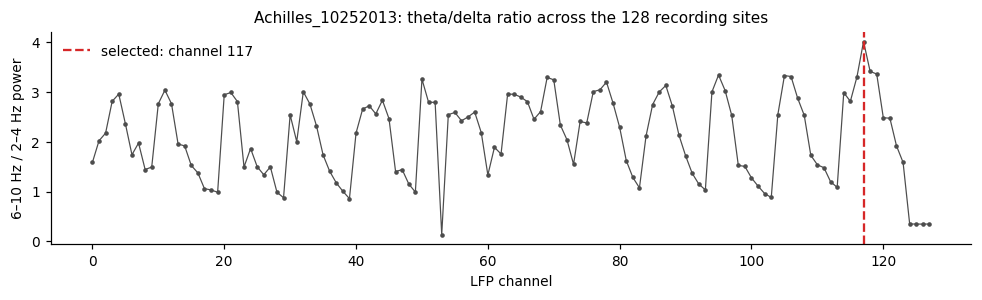

In [4]:
def pick_theta_channel(nwbfile, maze, n_probe=128, window=300.0):
    es = nwbfile.processing["ecephys"]["LFP"]["LFP"]
    fs = es.rate
    i0 = int((maze.start[0] + 120.0) * fs)
    i1 = i0 + int(window * fs)
    ratios = np.zeros(n_probe)
    for ch in tqdm(range(n_probe), desc="theta/delta scan", leave=False):
        f, p = welch(es.data[i0:i1, ch].astype(np.float64), fs=fs, nperseg=int(4 * fs))
        ratios[ch] = p[(f >= 6) & (f <= 10)].mean() / p[(f >= 2) & (f <= 4)].mean()
    return int(np.argmax(ratios)), ratios


maze = epochs["MazeEpoch"]
theta_ch, ratios = pick_theta_channel(nwbfile, maze)
print(f"theta reference channel: {theta_ch}  (theta/delta = {ratios[theta_ch]:.2f})")

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(ratios, ".-", color="0.3", lw=0.8, ms=4)
ax.axvline(theta_ch, color="C3", ls="--", label=f"selected: channel {theta_ch}")
ax.set_xlabel("LFP channel"); ax.set_ylabel("6–10 Hz / 2–4 Hz power")
ax.set_title(f"{EXAMPLE}: theta/delta ratio across the 128 recording sites")
ax.legend(); fig.tight_layout()
fig.savefig("fig00_theta_channel_selection.png", bbox_inches="tight")

## 4. Extracting theta phase

The chosen channel is band-passed to 6–10 Hz with a 4th-order Butterworth filter
and the instantaneous phase is taken from the Hilbert transform of the filtered
signal. Phase 0 corresponds to the **peak** of the band-passed LFP on the
reference channel; the absolute offset depends on recording depth, so only
relative phase (across cells, and across position within a field) is
interpretable without a depth-calibrated reference.

In [5]:
def theta_phase_amp(lfp, fs, band=THETA_BAND):
    filt = nap.apply_bandpass_filter(lfp, band, fs=fs, mode="butter", order=4)
    analytic = hilbert(filt.values)
    phase = nap.Tsd(t=filt.t, d=np.mod(np.angle(analytic), 2 * np.pi))
    amp = nap.Tsd(t=filt.t, d=np.abs(analytic))
    return phase, amp, filt


lfp, fs = get_lfp(nwbfile, theta_ch, maze)
phase, amp, filt = theta_phase_amp(lfp, fs)
print(f"LFP: {len(lfp):,} samples at {fs:g} Hz over {maze.tot_length():.0f} s")

LFP: 2,584,375 samples at 1250 Hz over 2068 s


## 5. Behavior: extracting laps and running epochs

Each contiguous block of valid linearized samples is one traversal. A block is
kept as a lap if it lasts at least 0.5 s, crosses at least half the track, and
has a mean speed above 0.1 m/s; it is labelled by the sign of its net
displacement. Within a lap, only the samples where instantaneous speed exceeds
0.1 m/s are used, which trims the acceleration and deceleration at the ends.

In [6]:
def run_epochs(position, dt, track_len, speed_thresh=SPEED_THRESH,
               min_dur=MIN_RUN_DUR):
    t, x = position.t, position.values
    brk = np.where(np.diff(t) > 3 * dt)[0]          # gaps start a new lap
    starts, stops = np.r_[0, brk + 1], np.r_[brk, len(t) - 1]

    ep_start, ep_end, direction = [], [], []
    for a, b in zip(starts, stops):
        if b - a < 5:
            continue
        dur, disp = t[b] - t[a], x[b] - x[a]
        if dur < min_dur or abs(disp) < 0.5 * track_len:
            continue
        if abs(disp) / dur < speed_thresh:
            continue
        ep_start.append(t[a]); ep_end.append(t[b])
        direction.append(1 if disp > 0 else -1)
    return (nap.IntervalSet(start=np.array(ep_start), end=np.array(ep_end)),
            np.array(direction))


def speed_tsd(position, smooth_s=0.25):
    v = np.clip(np.abs(np.gradient(position.values, position.t)), 0, 3.0)
    return nap.Tsd(t=position.t, d=v,
                   time_support=position.time_support).smooth(smooth_s, size_factor=20)


position, dt, track_len = get_position(nwbfile)
runs, direction = run_epochs(position, dt, track_len)
speed = speed_tsd(position)
moving = speed.threshold(SPEED_THRESH).time_support

dir_eps = {}
for lbl, sgn in [("R", 1), ("L", -1)]:
    idx = np.where(direction == sgn)[0]
    e = nap.IntervalSet(start=runs.start[idx], end=runs.end[idx])
    dir_eps[lbl] = e.intersect(moving).drop_short_intervals(0.2)
all_run = dir_eps["R"].union(dir_eps["L"])

print(f"track length {track_len:.1f} m, position sampled at {1/dt:.1f} Hz")
print(f"{len(runs)} laps ({(direction > 0).sum()} left→right, "
      f"{(direction < 0).sum()} right→left)")
print(f"running time used: {all_run.tot_length():.0f} s "
      f"(R {dir_eps['R'].tot_length():.0f} s, L {dir_eps['L'].tot_length():.0f} s)")
print(f"median speed while running: "
      f"{np.median(speed.restrict(all_run).values):.2f} m/s")

track length 1.6 m, position sampled at 39.1 Hz
83 laps (41 left→right, 42 right→left)
running time used: 205 s (R 108 s, L 98 s)
median speed while running: 0.64 m/s


### Figure 1 — raw data and the theta rhythm

One traversal of the track with all four streams aligned: position, raw and
band-passed LFP, the reconstructed theta phase, and the spike raster of all
simultaneously recorded excitatory units. The power spectrum over all running
time shows the theta peak near 8 Hz together with its harmonic near 16 Hz.

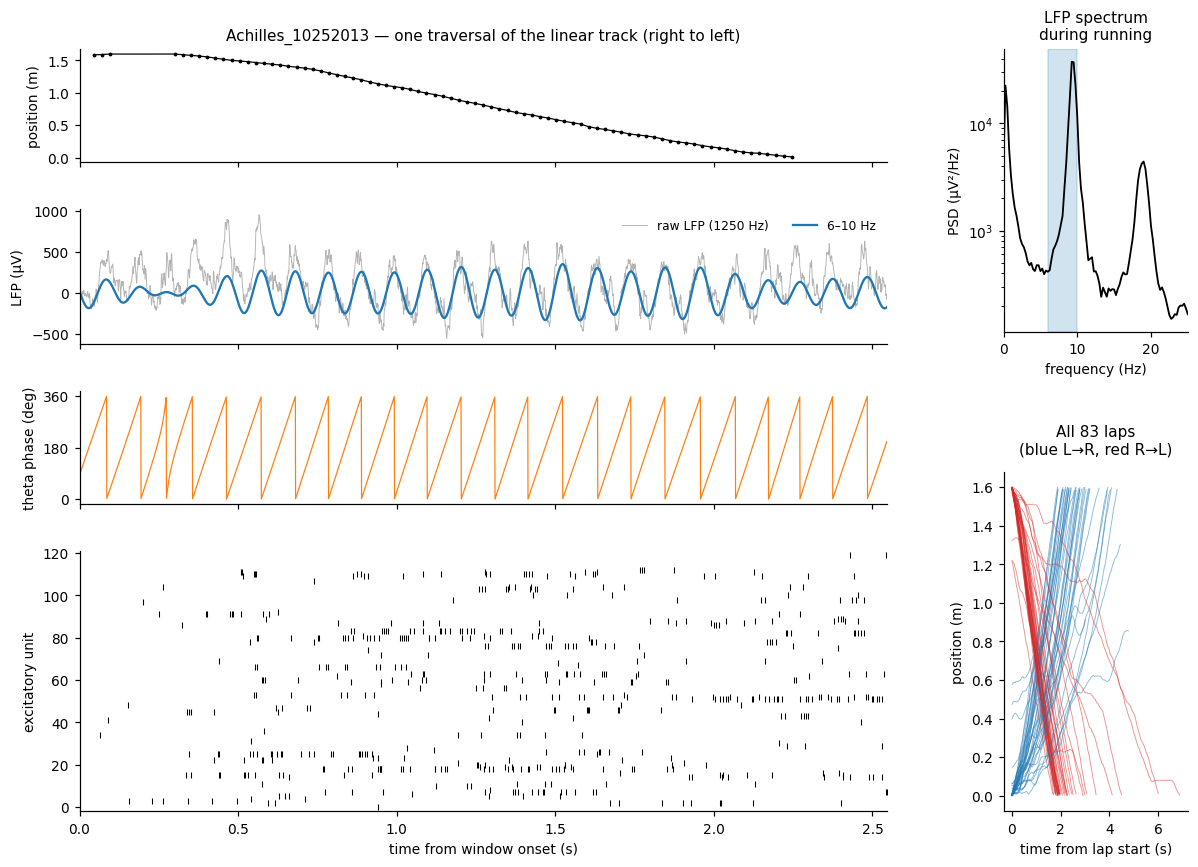

In [7]:
units = get_units(nwbfile).restrict(maze)
psd_f, psd_p = welch(lfp.restrict(all_run).values, fs=fs, nperseg=int(4 * fs))
lap_idx = 10

lap = runs[lap_idx]
win = nap.IntervalSet(start=lap.start[0] - 0.3, end=lap.end[0] + 0.3)
t0 = win.start[0]

fig = plt.figure(figsize=(13, 9))
gs = GridSpec(4, 3, height_ratios=[1, 1.2, 1, 2.3], width_ratios=[3, 3, 1.6],
              hspace=0.3, wspace=0.4)

ax = fig.add_subplot(gs[0, :2])
ax.plot(position.restrict(win).t - t0, position.restrict(win).values,
        "k.-", ms=3, lw=0.8)
ax.set_ylabel("position (m)")
ax.set_title(f"{EXAMPLE} — one traversal of the linear track "
             f"({'left to right' if direction[lap_idx] > 0 else 'right to left'})")

ax2 = fig.add_subplot(gs[1, :2], sharex=ax)
ax2.plot(lfp.restrict(win).t - t0, lfp.restrict(win).values, color="0.7", lw=0.6,
         label="raw LFP (1250 Hz)")
ax2.plot(filt.restrict(win).t - t0, filt.restrict(win).values, color="C0", lw=1.5,
         label="6–10 Hz")
ax2.set_ylabel("LFP (µV)"); ax2.legend(loc="upper right", ncol=2, fontsize=8)

ax3 = fig.add_subplot(gs[2, :2], sharex=ax)
ax3.plot(phase.restrict(win).t - t0, np.degrees(phase.restrict(win).values),
         color="C1", lw=0.8)
ax3.set_ylabel("theta phase (deg)"); ax3.set_yticks([0, 180, 360])

ax4 = fig.add_subplot(gs[3, :2], sharex=ax)
exc = units[np.array(units.cell_type) == "excitatory"]
for k, uid in enumerate(exc.index):
    st = exc[uid].restrict(win)
    ax4.plot(st.t - t0, np.full(len(st), k), "|", color="k", ms=3.5, mew=0.7)
ax4.set_ylabel("excitatory unit"); ax4.set_xlabel("time from window onset (s)")
ax4.set_ylim(-2, len(exc.index) + 1); ax4.set_xlim(0, win.end[0] - t0)
for a in (ax, ax2, ax3):
    a.tick_params(labelbottom=False)

rgs = gs[:, 2].subgridspec(2, 1, hspace=0.45, height_ratios=[1, 1.2])
axp = fig.add_subplot(rgs[0])
vis = psd_f <= 25
axp.semilogy(psd_f[vis], psd_p[vis], "k", lw=1.2)
axp.axvspan(6, 10, color="C0", alpha=0.2)
axp.set_xlim(0, 25); axp.set_xlabel("frequency (Hz)"); axp.set_ylabel("PSD (µV²/Hz)")
axp.set_title("LFP spectrum\nduring running")

axl = fig.add_subplot(rgs[1])
for i in range(len(runs)):
    p = position.restrict(runs[i])
    axl.plot(p.t - p.t[0], p.values, lw=0.6,
             color=("C0" if direction[i] > 0 else "C3"), alpha=0.5)
axl.set_xlabel("time from lap start (s)"); axl.set_ylabel("position (m)")
axl.set_title(f"All {len(runs)} laps\n(blue L→R, red R→L)", pad=12)
fig.savefig("fig01_raw_data_and_theta.png", bbox_inches="tight")

## 6. Place fields

Firing-rate maps are computed with `nap.compute_tuning_curves` in 4 cm bins,
separately for the two running directions (CA1 place fields on a linear track
are strongly directional), and smoothed with a one-bin Gaussian. A unit is
counted as having a place field in a given direction if its peak rate is at
least 1 Hz, its Skaggs spatial information is at least 0.4 bits/spike, the
contiguous region above 20% of peak is between 12 and 90 cm wide, and it fires
at least 50 spikes inside that region.

In [8]:
def tuning_curves(units, position, epochs, n_bins, track, smooth_bins=1.0):
    tc = nap.compute_tuning_curves(units, position, bins=n_bins, range=[track],
                                   epochs=epochs, return_pandas=True).fillna(0.0)
    if smooth_bins > 0:
        tc.loc[:, :] = gaussian_filter1d(tc.values, smooth_bins, axis=0,
                                         mode="nearest")
    return tc


def occupancy(position, epochs, n_bins, track, dt):
    counts, edges = np.histogram(position.restrict(epochs).values,
                                 bins=n_bins, range=track)
    return counts * dt, edges


def spatial_information(rate_map, occ):
    """Skaggs spatial information, bits per spike."""
    p = occ / occ.sum()
    mean_rate = np.sum(p * rate_map)
    if mean_rate <= 0:
        return 0.0
    nz = (rate_map > 0) & (p > 0)
    return float(np.sum(p[nz] * (rate_map[nz] / mean_rate)
                        * np.log2(rate_map[nz] / mean_rate)))


def find_field(rate_map, centers, frac=0.2):
    """Contiguous bins around the peak where rate >= frac * peak."""
    pk = int(np.argmax(rate_map))
    if rate_map[pk] <= 0:
        return None
    thr = frac * rate_map[pk]
    lo = hi = pk
    while lo > 0 and rate_map[lo - 1] >= thr:
        lo -= 1
    while hi < len(rate_map) - 1 and rate_map[hi + 1] >= thr:
        hi += 1
    bw = centers[1] - centers[0]
    return centers[lo] - bw / 2, centers[hi] + bw / 2, centers[pk], float(rate_map[pk])

## 7. Circular statistics and the circular–linear regression

Theta phase is a circular variable, so entrainment is quantified with the mean
resultant length (MRL) and the Rayleigh test for non-uniformity.

Phase precession relates a circular variable (spike phase) to a linear one
(position within the field), which ordinary linear regression cannot handle.
We use the procedure of Kempter et al. (2012): the slope `a` is the value that
maximises the resultant length of `exp(i(φ − 2πa·x))`, the offset is the
argument of that resultant, and the correlation `ρ` is the circular analogue of
Pearson's r. Significance is assessed by permutation — phases are shuffled
against positions 500 times and the maximum resultant over the slope grid is
recomputed, giving a null distribution for exactly the quantity the fit
optimises. This avoids relying on the asymptotic approximation, which is
unreliable for the modest spike counts of single place fields.

In [9]:
def circ_mean(alpha):
    return np.mod(np.angle(np.mean(np.exp(1j * np.asarray(alpha)))), 2 * np.pi)


def rayleigh_test(alpha):
    """Rayleigh test for circular non-uniformity. Returns (p, z, MRL)."""
    alpha = np.asarray(alpha)
    n = len(alpha)
    r = np.abs(np.mean(np.exp(1j * alpha)))
    z = n * r ** 2
    p = np.exp(np.sqrt(1 + 4 * n + 4 * (n ** 2 - (n * r) ** 2)) - (1 + 2 * n))
    return p, z, r


def circlin_fit(x, phi, slope_range=(-2.0, 2.0), n_slopes=401):
    """Kempter et al. (2012) circular-linear regression.

    Returns (slope in cycles per unit x, phase offset in rad, rho).
    """
    x, phi = np.asarray(x, float), np.asarray(phi, float)
    slopes = np.linspace(*slope_range, n_slopes)
    M = np.exp(-2j * np.pi * np.outer(slopes, x))
    a = slopes[int(np.argmax(np.abs(M @ np.exp(1j * phi))))]
    phi0 = np.mod(np.angle(np.mean(np.exp(1j * (phi - 2 * np.pi * a * x)))), 2 * np.pi)

    theta = np.mod(2 * np.pi * abs(a) * x, 2 * np.pi)
    phi_bar, th_bar = np.angle(np.mean(np.exp(1j * phi))), np.angle(np.mean(np.exp(1j * theta)))
    num = np.sum(np.sin(phi - phi_bar) * np.sin(theta - th_bar))
    den = np.sqrt(np.sum(np.sin(phi - phi_bar) ** 2) * np.sum(np.sin(theta - th_bar) ** 2))
    return float(a), float(phi0), float(num / den) if den > 0 else 0.0


def circlin_permutation_p(x, phi, n_perm=N_PERM, seed=0,
                          slope_range=(-2.0, 2.0), n_slopes=401):
    rng = np.random.default_rng(seed)
    x, phi = np.asarray(x, float), np.asarray(phi, float)
    n = len(x)
    slopes = np.linspace(*slope_range, n_slopes)
    M = np.exp(-2j * np.pi * np.outer(slopes, x))
    obs = np.abs(M @ np.exp(1j * phi)).max() / n
    perms = np.stack([rng.permutation(phi) for _ in range(n_perm)], axis=1)
    null = np.abs(M @ np.exp(1j * perms)).max(axis=0) / n
    return float((np.sum(null >= obs) + 1) / (n_perm + 1)), float(obs)

## 8. The per-session pipeline

Everything above is assembled into one function that runs on a session and
returns per-unit entrainment statistics, per-field precession fits, and the
spike-level phase/position table used for the population figures.

In [10]:
def theta_frequency(phase, ep):
    ph = phase.restrict(ep)
    d = np.mod(np.diff(ph.values) + np.pi, 2 * np.pi) - np.pi
    dt_ = np.diff(ph.t)
    ok = dt_ < 0.01
    return float(np.mean(d[ok]) / np.mean(dt_[ok]) / (2 * np.pi))


def analyze_session(session):
    nwbfile = open_session(session)
    maze = get_epochs(nwbfile)["MazeEpoch"]
    ch, _ = pick_theta_channel(nwbfile, maze)
    lfp, fs = get_lfp(nwbfile, ch, maze)
    phase, amp, filt = theta_phase_amp(lfp, fs)

    position, dt, track_len = get_position(nwbfile)
    track, n_bins = (0.0, track_len), int(round(track_len / BIN_SIZE))
    runs, direction = run_epochs(position, dt, track_len)
    moving = speed_tsd(position).threshold(SPEED_THRESH).time_support

    dir_eps = {}
    for lbl, sgn in [("R", 1), ("L", -1)]:
        idx = np.where(direction == sgn)[0]
        e = nap.IntervalSet(start=runs.start[idx], end=runs.end[idx])
        dir_eps[lbl] = e.intersect(moving).drop_short_intervals(0.2)
    all_run = dir_eps["R"].union(dir_eps["L"])

    units = get_units(nwbfile).restrict(maze)

    # mean band-passed LFP per theta phase bin, to show the phase convention
    ph_run, fl_run = phase.restrict(all_run), filt.restrict(all_run)
    wave_edges = np.linspace(0, 2 * np.pi, 73)
    wbin = np.digitize(ph_run.values, wave_edges) - 1
    mean_wave = np.array([fl_run.values[wbin == b].mean() for b in range(72)])
    wave_centers = (wave_edges[:-1] + wave_edges[1:]) / 2

    # ---- theta phase entrainment -------------------------------------------
    entrain, phase_hists = [], {}
    for uid in units.index:
        st = units[uid].restrict(all_run)
        if len(st) < 30:
            continue
        ph = st.value_from(phase).values
        ph = ph[np.isfinite(ph)]
        phase_hists[uid] = np.histogram(ph, bins=wave_edges)[0]
        p, z, r = rayleigh_test(ph)
        entrain.append(dict(session=session, unit=uid,
                            cell_type=units.cell_type[uid],
                            location=units.location[uid], n_spikes=len(ph),
                            mrl=r, rayleigh_z=z, rayleigh_p=p,
                            pref_phase=circ_mean(ph),
                            rate=len(st) / all_run.tot_length()))
    entrain = pd.DataFrame(entrain)

    # ---- place fields and phase precession ---------------------------------
    cells, spike_rows, rate_maps = [], [], {}
    for lbl in ["R", "L"]:
        ep = dir_eps[lbl]
        tc = tuning_curves(units, position, ep, n_bins, track)
        rate_maps[lbl] = tc
        centers = tc.index.values.astype(float)
        occ, _ = occupancy(position, ep, n_bins, track, dt)

        for uid in units.index:
            if units.cell_type[uid] != "excitatory":
                continue
            rm = tc[uid].values
            fld = find_field(rm, centers)
            if fld is None:
                continue
            f0, f1, pk_pos, pk_rate = fld
            width = f1 - f0
            si = spatial_information(rm, occ)
            pos_at_spike = units[uid].restrict(ep).value_from(position)
            m = (pos_at_spike.values >= f0) & (pos_at_spike.values <= f1)

            rec = dict(session=session, unit=uid, direction=lbl, peak_rate=pk_rate,
                       peak_pos=pk_pos, field_start=f0, field_end=f1,
                       field_width=width, spatial_info=si,
                       n_spikes_field=int(m.sum()), is_place_cell=False,
                       slope=np.nan, phase0=np.nan, rho=np.nan, perm_p=np.nan)

            if (pk_rate >= MIN_PEAK_RATE and si >= MIN_SI
                    and MIN_FIELD_W <= width <= MAX_FIELD_W
                    and m.sum() >= MIN_SPIKES_FIELD):
                xs, ts = pos_at_spike.values[m], pos_at_spike.t[m]
                phs = nap.Ts(t=ts).value_from(phase).values
                good = np.isfinite(phs) & np.isfinite(xs)
                xs, ts, phs = xs[good], ts[good], phs[good]
                # normalized position within the field, oriented along travel
                xn = (xs - f0) / width
                if lbl == "L":
                    xn = 1.0 - xn
                a, phi0, rho = circlin_fit(xn, phs)
                pp, _ = circlin_permutation_p(xn, phs, seed=uid)
                rec.update(is_place_cell=True, slope=a, phase0=phi0, rho=rho,
                           perm_p=pp)
                spike_rows.append(pd.DataFrame(dict(
                    session=session, unit=uid, direction=lbl, t=ts,
                    x_norm=xn, phase=phs)))
            cells.append(rec)

    return dict(session=session, channel=ch, fs=fs, track_len=track_len,
                n_laps=len(runs), run_time=all_run.tot_length(),
                n_units=len(units), entrain=entrain,
                cells=pd.DataFrame(cells),
                spikes=pd.concat(spike_rows, ignore_index=True) if spike_rows
                else pd.DataFrame(),
                rate_maps=rate_maps, phase_hists=phase_hists,
                phase_edges=wave_edges, mean_wave=mean_wave,
                wave_centers=wave_centers,
                mean_theta_freq=theta_frequency(phase, all_run))

In [11]:
results = []
for s in tqdm(list(ASSETS), desc="sessions"):
    r = analyze_session(s)
    pc = r["cells"][r["cells"].is_place_cell]
    print(f"{s}: {r['n_laps']} laps, {r['run_time']:.0f} s running, "
          f"{len(r['entrain'])} units "
          f"({int((r['entrain'].rayleigh_p < 0.01).sum())} theta-locked), "
          f"{len(pc)} place fields "
          f"({int((pc.perm_p < 0.05).sum())} precessing)")
    results.append(r)

res_by_session = {r["session"]: r for r in results}
ex = res_by_session[EXAMPLE]
all_cells = pd.concat([r["cells"] for r in results], ignore_index=True)
all_spikes = pd.concat([r["spikes"] for r in results], ignore_index=True)
all_entrain = pd.concat([r["entrain"] for r in results], ignore_index=True)
hists = {(r["session"], u): h for r in results for u, h in r["phase_hists"].items()}
edges = results[0]["phase_edges"]
pcs = all_cells[all_cells.is_place_cell]

sessions:   0%|          | 0/5 [00:00<?, ?it/s]

theta/delta scan:   0%|          | 0/128 [00:00<?, ?it/s]

Achilles_10252013: 83 laps, 205 s running, 117 units (81 theta-locked), 78 place fields (63 precessing)


theta/delta scan:   0%|          | 0/128 [00:00<?, ?it/s]

Buddy_06272013: 53 laps, 131 s running, 44 units (32 theta-locked), 14 place fields (10 precessing)


...

Cicero_09012014: 84 laps, 365 s running, 65 units (39 theta-locked), 20 place fields (14 precessing)


theta/delta scan:   0%|          | 0/128 [00:00<?, ?it/s]

Cicero_09172014: 48 laps, 295 s running, 63 units (38 theta-locked), 20 place fields (12 precessing)


theta/delta scan:   0%|          | 0/128 [00:00<?, ?it/s]

Gatsby_08022013: 83 laps, 289 s running, 57 units (43 theta-locked), 23 place fields (17 precessing)


### Figure 2 — directional place fields

Normalized rate maps for every accepted place field, sorted by the position of
the field peak, plus four example fields showing the strong directionality that
is typical of CA1 on a linear track.

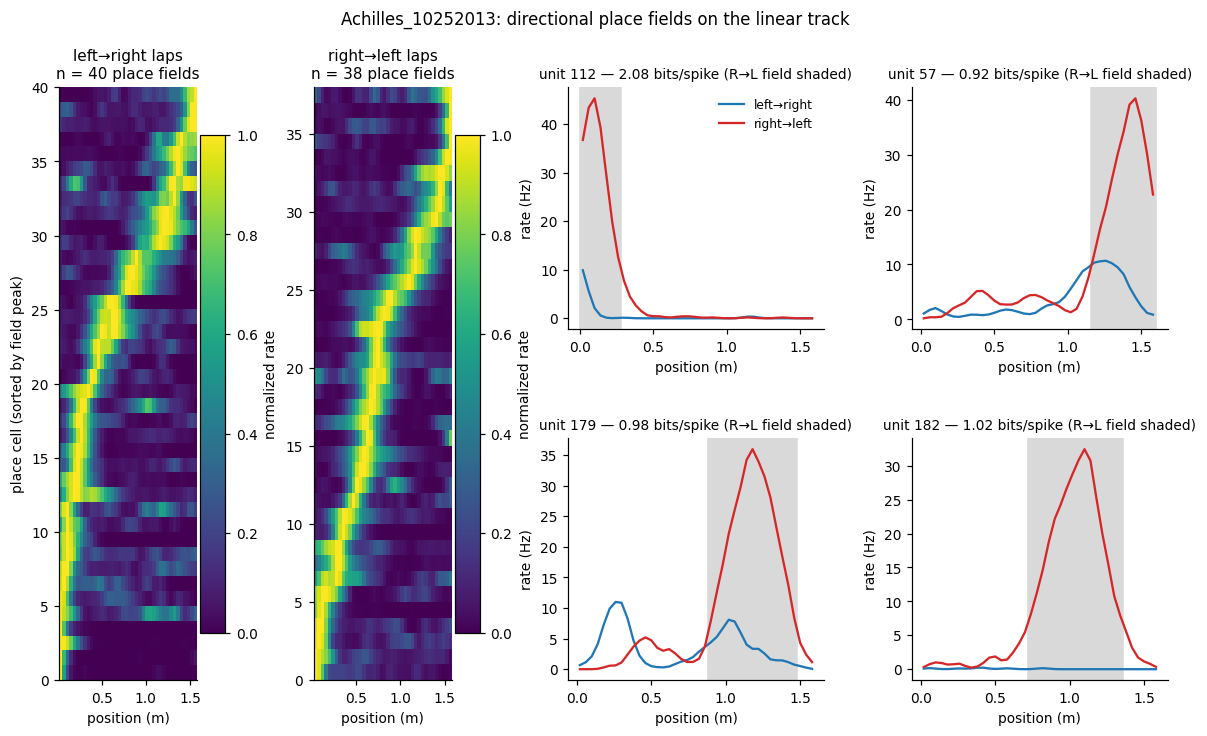

In [12]:
fig = plt.figure(figsize=(13, 7))
gs = GridSpec(2, 4, width_ratios=[1.3, 1.3, 2, 2], hspace=0.45, wspace=0.42)
cells = ex["cells"]

for j, lbl in enumerate(["R", "L"]):
    tc = ex["rate_maps"][lbl]
    sel = cells[(cells.direction == lbl) & cells.is_place_cell]
    ids = sel.sort_values("peak_pos").unit.values
    M = tc[ids].values.T
    M = M / np.maximum(M.max(axis=1, keepdims=True), 1e-9)
    ax = fig.add_subplot(gs[:, j])
    im = ax.imshow(M, aspect="auto", origin="lower", cmap="viridis",
                   extent=[tc.index[0], tc.index[-1], 0, len(ids)],
                   interpolation="nearest")
    ax.set_xlabel("position (m)")
    ax.set_ylabel("place cell (sorted by field peak)" if j == 0 else "")
    ax.set_title(f"{'left→right' if lbl == 'R' else 'right→left'} laps\n"
                 f"n = {len(ids)} place fields")
    plt.colorbar(im, ax=ax, label="normalized rate", pad=0.02)

picks = (cells[cells.is_place_cell].sort_values("peak_rate", ascending=False)
         .drop_duplicates("unit").head(4))
for k, (_, row) in enumerate(picks.iterrows()):
    ax = fig.add_subplot(gs[k // 2, 2 + k % 2])
    for lbl, c in [("R", "C0"), ("L", "C3")]:
        tc = ex["rate_maps"][lbl]
        ax.plot(tc.index, tc[row.unit].values, color=c, lw=1.5,
                label="left→right" if lbl == "R" else "right→left")
    ax.axvspan(row.field_start, row.field_end, color="0.85", zorder=0)
    ax.set_title(f"unit {int(row.unit)} — {row.spatial_info:.2f} bits/spike "
                 f"({'L→R' if row.direction == 'R' else 'R→L'} field shaded)",
                 fontsize=9)
    ax.set_xlabel("position (m)"); ax.set_ylabel("rate (Hz)")
    if k == 0:
        ax.legend(fontsize=8)
fig.suptitle(f"{EXAMPLE}: directional place fields on the linear track", y=0.98)
fig.savefig("fig02_place_fields.png", bbox_inches="tight")

### Figure 3 — theta phase entrainment

Spikes from both cell classes cluster at a preferred theta phase. Interneurons
are the more strongly locked population, as expected, but the great majority of
pyramidal cells are significantly non-uniform as well, and the effect is
reproducible across all five sessions.

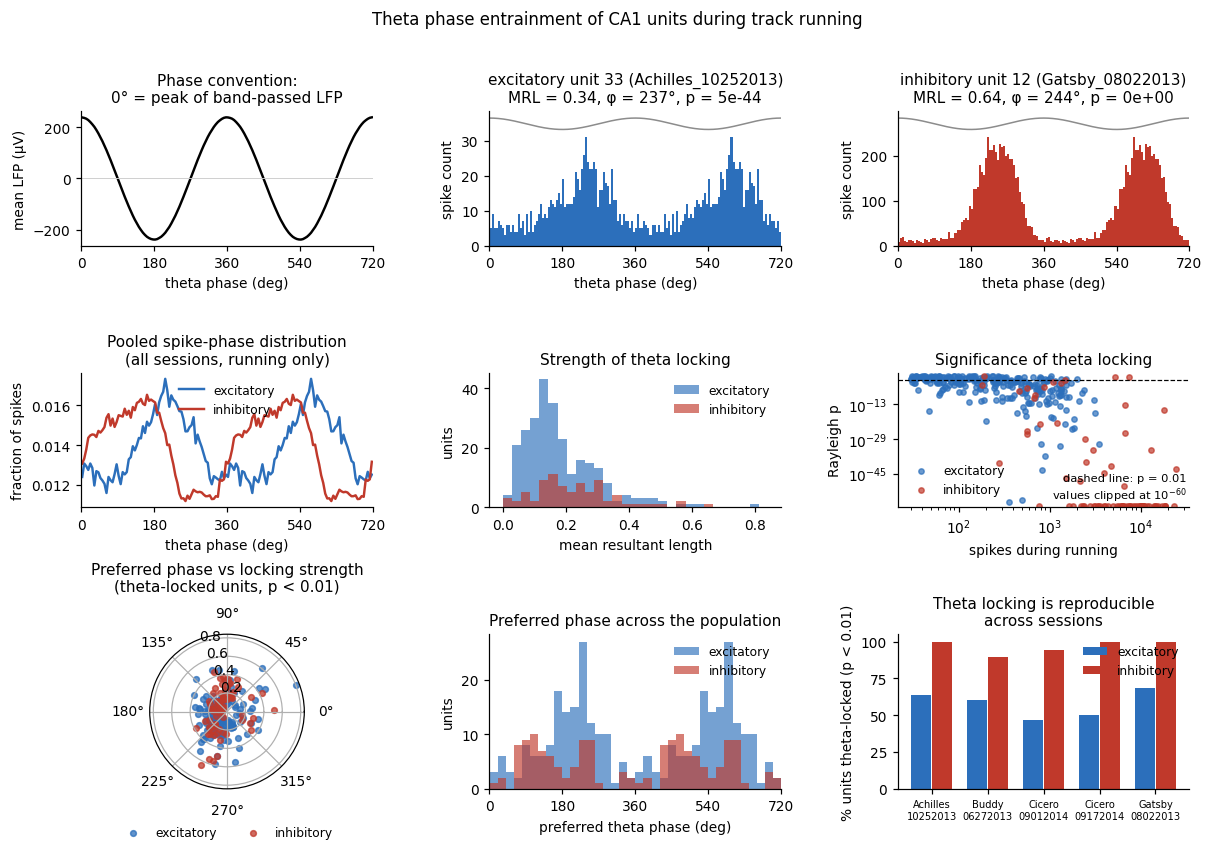

In [13]:
def phase_axis(ax, n_cycles=2):
    ax.set_xlim(0, n_cycles * 2 * np.pi)
    ticks = np.arange(0, n_cycles * 2 * np.pi + 0.1, np.pi)
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{int(np.degrees(t))}" for t in ticks])


def theta_guide(ax, n_cycles=2, color="0.55"):
    x = np.linspace(0, n_cycles * 2 * np.pi, 400)
    y0, y1 = ax.get_ylim()
    ax.set_ylim(y0, y1 * 1.18)
    a = 0.05 * (y1 - y0)
    ax.plot(x, y1 * 1.12 - a + a * np.cos(x), color=color, lw=1.0)


fig = plt.figure(figsize=(13, 8))
gs = GridSpec(3, 3, hspace=0.9, wspace=0.4, height_ratios=[1, 1, 1.15])
ctr = (edges[:-1] + edges[1:]) / 2
bw = edges[1] - edges[0]

ax = fig.add_subplot(gs[0, 0])
ax.plot(np.r_[ctr, ctr + 2 * np.pi], np.r_[ex["mean_wave"], ex["mean_wave"]],
        "k", lw=1.6)
phase_axis(ax); ax.axhline(0, color="0.8", lw=0.6)
ax.set_xlabel("theta phase (deg)"); ax.set_ylabel("mean LFP (µV)")
ax.set_title("Phase convention:\n0° = peak of band-passed LFP")

for k, ctype in enumerate(["excitatory", "inhibitory"]):
    sub = all_entrain[(all_entrain.cell_type == ctype) & (all_entrain.n_spikes > 500)]
    row = sub.sort_values("mrl", ascending=False).iloc[0]
    h = hists[(row.session, row.unit)]
    ax = fig.add_subplot(gs[0, 1 + k])
    ax.bar(np.r_[ctr, ctr + 2 * np.pi], np.r_[h, h], width=bw,
           color=EXC_C if ctype == "excitatory" else INH_C)
    phase_axis(ax)
    ax.set_xlabel("theta phase (deg)"); ax.set_ylabel("spike count")
    ax.set_title(f"{ctype} unit {int(row.unit)} ({row.session})\n"
                 f"MRL = {row.mrl:.2f}, φ = {np.degrees(row.pref_phase):.0f}°, "
                 f"p = {row.rayleigh_p:.0e}")
    theta_guide(ax)

ax = fig.add_subplot(gs[1, 0])
for ctype, c in [("excitatory", EXC_C), ("inhibitory", INH_C)]:
    pooled = np.sum([hists[(r.session, r.unit)] for _, r in
                     all_entrain[all_entrain.cell_type == ctype].iterrows()],
                    axis=0).astype(float)
    pooled /= pooled.sum()
    ax.plot(np.r_[ctr, ctr + 2 * np.pi], np.r_[pooled, pooled], color=c, lw=1.6,
            label=ctype)
phase_axis(ax); ax.legend(fontsize=8)
ax.set_xlabel("theta phase (deg)"); ax.set_ylabel("fraction of spikes")
ax.set_title("Pooled spike-phase distribution\n(all sessions, running only)")

ax = fig.add_subplot(gs[1, 1])
bins = np.linspace(0, all_entrain.mrl.max() * 1.05, 30)
for ctype, c in [("excitatory", EXC_C), ("inhibitory", INH_C)]:
    ax.hist(all_entrain[all_entrain.cell_type == ctype].mrl, bins=bins, alpha=0.65,
            color=c, label=ctype)
ax.set_xlabel("mean resultant length"); ax.set_ylabel("units")
ax.set_title("Strength of theta locking"); ax.legend(fontsize=8)

ax = fig.add_subplot(gs[1, 2])
for ctype, c in [("excitatory", EXC_C), ("inhibitory", INH_C)]:
    s = all_entrain[all_entrain.cell_type == ctype]
    ax.scatter(s.n_spikes, np.maximum(s.rayleigh_p, 1e-60), s=12, color=c,
               alpha=0.7, label=ctype)
ax.axhline(0.01, color="k", ls="--", lw=0.8)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_ylim(3e-61, 30)
ax.text(0.99, 0.02, "dashed line: p = 0.01\nvalues clipped at $10^{-60}$", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=7.5)
ax.set_xlabel("spikes during running")
ax.set_ylabel("Rayleigh p")
ax.set_title("Significance of theta locking"); ax.legend(fontsize=8, loc="lower left")

ax = fig.add_subplot(gs[2, 0], projection="polar")
for ctype, c in [("excitatory", EXC_C), ("inhibitory", INH_C)]:
    s = all_entrain[(all_entrain.cell_type == ctype) & (all_entrain.rayleigh_p < 0.01)]
    ax.scatter(s.pref_phase, s.mrl, s=14, color=c, alpha=0.75, label=ctype)
ax.set_rlabel_position(112)
ax.set_title("Preferred phase vs locking strength\n(theta-locked units, p < 0.01)",
             pad=28)
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=2)

ax = fig.add_subplot(gs[2, 1])
for ctype, c in [("excitatory", EXC_C), ("inhibitory", INH_C)]:
    s = all_entrain[(all_entrain.cell_type == ctype) & (all_entrain.rayleigh_p < 0.01)]
    ax.hist(np.r_[s.pref_phase, s.pref_phase + 2 * np.pi], bins=36,
            range=(0, 4 * np.pi), alpha=0.65, color=c, label=ctype)
phase_axis(ax); ax.legend(fontsize=8)
ax.set_xlabel("preferred theta phase (deg)"); ax.set_ylabel("units")
ax.set_title("Preferred phase across the population")

ax = fig.add_subplot(gs[2, 2])
g = (all_entrain.assign(sig=all_entrain.rayleigh_p < 0.01)
     .groupby(["session", "cell_type"]).sig.mean().unstack()
     .reindex(columns=["excitatory", "inhibitory"]))
xs = np.arange(len(g))
ax.bar(xs - 0.19, g["excitatory"] * 100, 0.36, color=EXC_C, label="excitatory")
ax.bar(xs + 0.19, g["inhibitory"] * 100, 0.36, color=INH_C, label="inhibitory")
ax.set_xticks(xs); ax.set_xticklabels([s.replace("_", "\n") for s in g.index],
                                      fontsize=6.5)
ax.set_ylabel("% units theta-locked (p < 0.01)"); ax.set_ylim(0, 105)
ax.legend(fontsize=8); ax.set_title("Theta locking is reproducible\nacross sessions")

fig.suptitle("Theta phase entrainment of CA1 units during track running", y=0.995)
fig.savefig("fig03_theta_entrainment.png", bbox_inches="tight")

### Figure 4 — phase precession in single place fields

For eight example fields: the rate map on top with the detected field shaded,
and below it every in-field spike plotted as normalized position against theta
phase, repeated over two cycles so the wrap-around is visible. The orange line
is the fitted circular–linear regression. Spikes at the field entrance occur
late in the theta cycle and shift steadily earlier as the animal crosses.

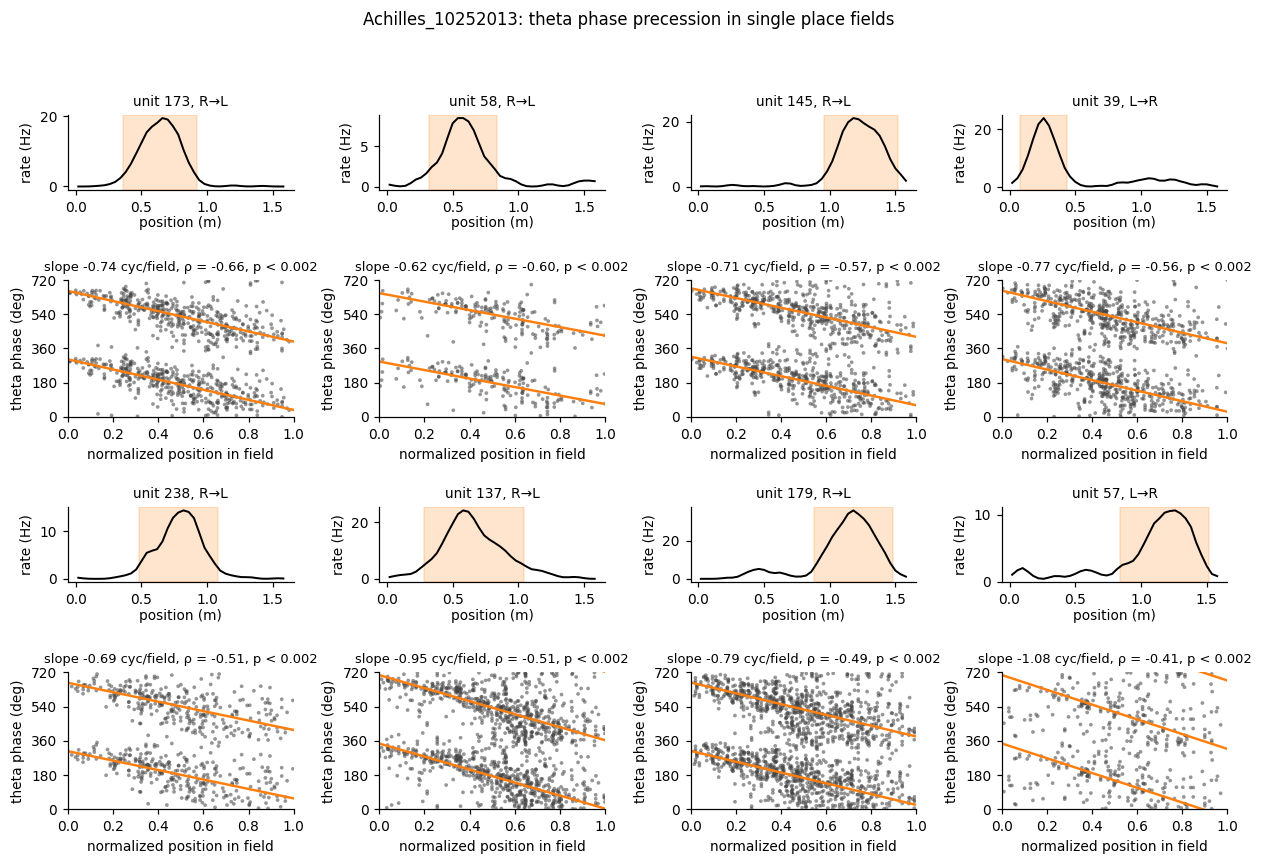

In [14]:
_c = ex["cells"]
_ok = (_c.is_place_cell & (_c.perm_p < 0.05) & (_c.slope < 0)
       & (_c.n_spikes_field >= 150) & (_c.field_start > 0.05)
       & (_c.field_end < ex["track_len"] - 0.05))
pick = _c[_ok].sort_values("rho").head(8)
ncol = 4
nrow = int(np.ceil(len(pick) / ncol))
fig, axes = plt.subplots(nrow * 2, ncol, figsize=(3.4 * ncol, 4.1 * nrow),
                         gridspec_kw={"height_ratios": [0.55, 1] * nrow,
                                      "hspace": 0.85, "wspace": 0.38})
axes = np.atleast_2d(axes)
for k, (_, row) in enumerate(pick.iterrows()):
    r, c = (k // ncol) * 2, k % ncol
    tc = ex["rate_maps"][row.direction]
    axr = axes[r, c]
    axr.plot(tc.index, tc[row.unit].values, color="k", lw=1.3)
    axr.axvspan(row.field_start, row.field_end, color="C1", alpha=0.2)
    axr.set_xlabel("position (m)", labelpad=1); axr.set_ylabel("rate (Hz)")
    axr.set_title(f"unit {int(row.unit)}, "
                  f"{'L→R' if row.direction == 'R' else 'R→L'}", fontsize=9)

    s = all_spikes[(all_spikes.session == row.session) & (all_spikes.unit == row.unit)
                   & (all_spikes.direction == row.direction)]
    ax = axes[r + 1, c]
    ax.scatter(np.r_[s.x_norm, s.x_norm],
               np.r_[np.degrees(s.phase), np.degrees(s.phase) + 360],
               s=6, color="0.25", alpha=0.55, edgecolors="none")
    xx = np.linspace(0, 1, 100)
    yy = np.degrees(row.phase0 + 2 * np.pi * row.slope * xx)
    for off in (-360, 0, 360, 720):
        ax.plot(xx, yy + off, color="C1", lw=1.6)
    ax.set_ylim(0, 720); ax.set_xlim(0, 1)
    ax.set_yticks([0, 180, 360, 540, 720])
    ax.set_xlabel("normalized position in field")
    ax.set_ylabel("theta phase (deg)")
    ptxt = "p < 0.002" if row.perm_p <= 2.0 / (N_PERM + 1) else f"p = {row.perm_p:.3f}"
    ax.set_title(f"slope {row.slope:.2f} cyc/field, ρ = {row.rho:.2f}, {ptxt}",
                 fontsize=8.5)
for k in range(len(pick), nrow * ncol):
    r, c = (k // ncol) * 2, k % ncol
    axes[r, c].axis("off"); axes[r + 1, c].axis("off")
fig.suptitle(f"{EXAMPLE}: theta phase precession in single place fields", y=0.995)
fig.savefig("fig04_precession_examples.png", bbox_inches="tight")

### Figure 5 — precession across the population

Pooling every significantly precessing field from all five sessions gives the
canonical negative diagonal band in the phase-versus-position density. The
fitted slopes are overwhelmingly negative, and the observed circular–linear
correlations lie far outside the shuffled null.

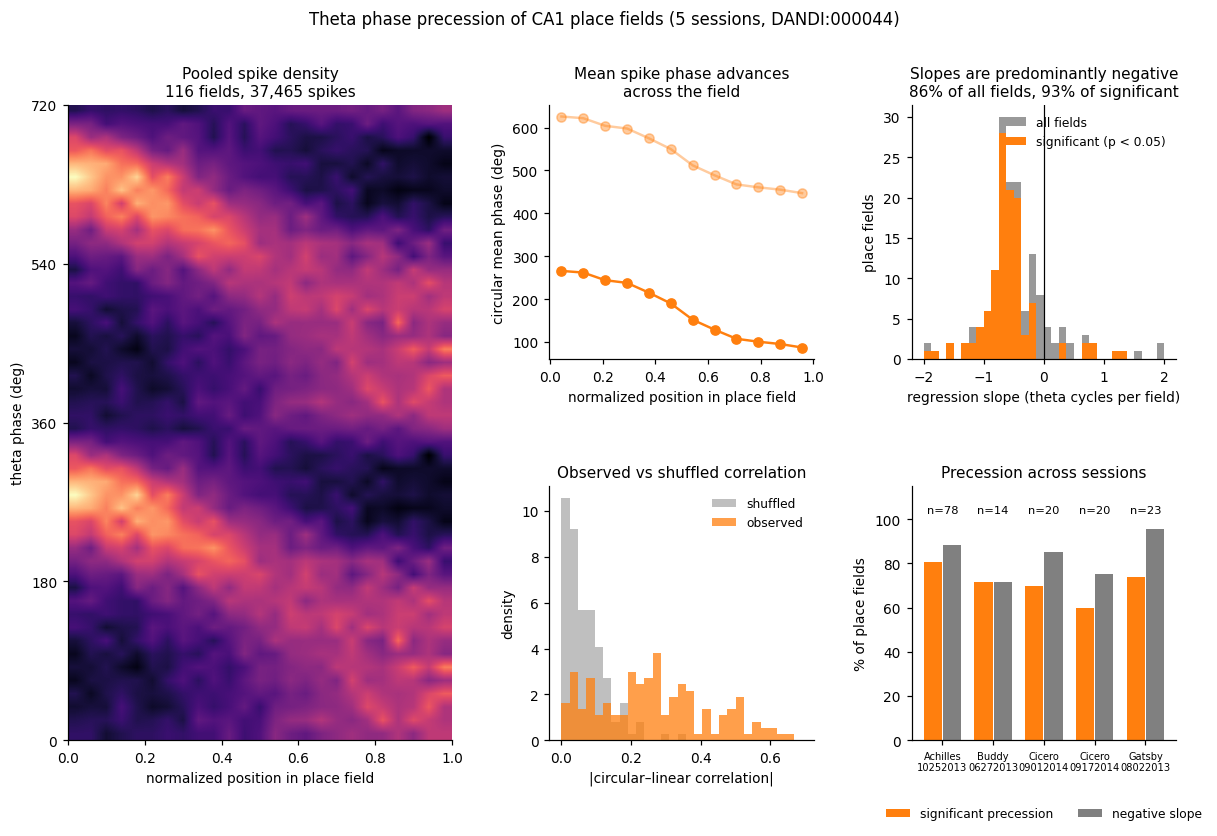

In [15]:
rng = np.random.default_rng(1)
null_rhos = np.array([abs(circlin_fit(s.x_norm.values,
                                      rng.permutation(s.phase.values))[2])
                      for _, s in all_spikes.groupby(["session", "unit", "direction"])])

sig = pcs[pcs.perm_p < 0.05]
sig_keys = set(zip(sig.session, sig.unit, sig.direction))
sp = all_spikes[[k in sig_keys for k in
                 zip(all_spikes.session, all_spikes.unit, all_spikes.direction)]]

fig = plt.figure(figsize=(13, 7.5))
gs = GridSpec(2, 3, hspace=0.5, wspace=0.32,
                  width_ratios=[1.45, 1, 1])

ax = fig.add_subplot(gs[:, 0])
H, _, _ = np.histogram2d(np.r_[sp.x_norm, sp.x_norm],
                         np.r_[np.degrees(sp.phase), np.degrees(sp.phase) + 360],
                         bins=[25, 48], range=[[0, 1], [0, 720]])
H = H / H.sum(axis=1, keepdims=True)
ax.imshow(H.T, origin="lower", aspect="auto", cmap="magma",
          extent=[0, 1, 0, 720], interpolation="bilinear")
ax.set_yticks([0, 180, 360, 540, 720])
ax.set_xlabel("normalized position in place field")
ax.set_ylabel("theta phase (deg)")
ax.set_title(f"Pooled spike density\n{len(sig)} fields, {len(sp):,} spikes")

ax = fig.add_subplot(gs[0, 1])
pos_edges = np.linspace(0, 1, 13)
idx = np.digitize(sp.x_norm.values, pos_edges) - 1
mus = np.degrees([circ_mean(sp.phase.values[idx == b]) if (idx == b).sum() > 20
                  else np.nan for b in range(len(pos_edges) - 1)])
pctr = (pos_edges[:-1] + pos_edges[1:]) / 2
for i in range(1, len(mus)):
    while mus[i] > mus[i - 1] + 180:
        mus[i] -= 360
ax.plot(pctr, mus, "o-", color="C1", lw=1.6)
ax.plot(pctr, mus + 360, "o-", color="C1", lw=1.6, alpha=0.4)
ax.set_xlabel("normalized position in place field")
ax.set_ylabel("circular mean phase (deg)")
ax.set_title("Mean spike phase advances\nacross the field")

ax = fig.add_subplot(gs[0, 2])
sbins = np.linspace(-2, 2, 33)
ax.hist(pcs.slope, bins=sbins, color="0.6", label="all fields")
ax.hist(sig.slope, bins=sbins, color="C1", label="significant (p < 0.05)")
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("regression slope (theta cycles per field)")
ax.set_ylabel("place fields"); ax.legend(fontsize=8)
ax.set_title(f"Slopes are predominantly negative\n"
             f"{100 * (pcs.slope < 0).mean():.0f}% of all fields, "
             f"{100 * (sig.slope < 0).mean():.0f}% of significant")

ax = fig.add_subplot(gs[1, 1])
rbins = np.linspace(0, max(np.abs(pcs.rho).max(), null_rhos.max()) * 1.05, 30)
ax.hist(null_rhos, bins=rbins, color="0.75", density=True, label="shuffled")
ax.hist(np.abs(pcs.rho), bins=rbins, color="C1", alpha=0.75, density=True,
        label="observed")
ax.set_xlabel("|circular–linear correlation|"); ax.set_ylabel("density")
ax.legend(fontsize=8); ax.set_title("Observed vs shuffled correlation")

ax = fig.add_subplot(gs[1, 2])
g = pcs.groupby("session").apply(
    lambda d: pd.Series({"n": len(d), "pct_sig": 100 * (d.perm_p < 0.05).mean(),
                         "pct_neg": 100 * (d.slope < 0).mean()}),
    include_groups=False)
xs = np.arange(len(g))
ax.bar(xs - 0.19, g.pct_sig, 0.36, color="C1", label="significant precession")
ax.bar(xs + 0.19, g.pct_neg, 0.36, color="0.5", label="negative slope")
for i, n in enumerate(g.n):
    ax.text(i, 103, f"n={int(n)}", ha="center", fontsize=7.5)
ax.set_xticks(xs); ax.set_xticklabels([s.replace("_", "\n") for s in g.index],
                                      fontsize=6.5)
ax.set_ylim(0, 115); ax.set_ylabel("% of place fields")
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2)
ax.set_title("Precession across sessions")

fig.suptitle("Theta phase precession of CA1 place fields (5 sessions, DANDI:000044)",
             y=0.995)
fig.savefig("fig05_precession_population.png", bbox_inches="tight")

## 9. Summary

In [16]:
summary = pd.DataFrame([{
    "session": r["session"],
    "track_len_m": r["track_len"],
    "theta_ch": r["channel"],
    "theta_freq_Hz": round(r["mean_theta_freq"], 2),
    "laps": r["n_laps"],
    "run_time_s": round(r["run_time"], 1),
    "units": r["n_units"],
    "units_tested": len(r["entrain"]),
    "theta_locked_p01": int((r["entrain"].rayleigh_p < 0.01).sum()),
    "place_fields": int(r["cells"].is_place_cell.sum()),
    "precessing_p05": int((r["cells"].perm_p < 0.05).sum()),
    "median_slope": round(float(r["cells"][r["cells"].is_place_cell].slope.median()), 3),
} for r in results])
summary.to_csv("session_summary.csv", index=False)
pcs.to_csv("place_field_precession.csv", index=False)
all_entrain.to_csv("theta_entrainment.csv", index=False)
print(summary.to_string(index=False))

          session  track_len_m  theta_ch  theta_freq_Hz  laps  run_time_s  units  units_tested  theta_locked_p01  place_fields  precessing_p05  median_slope
Achilles_10252013          1.6       117           9.34    83       205.2    137           117                81            78              63        -0.630
   Buddy_06272013          1.6        81           8.57    53       130.9     68            44                32            14              10        -0.420
  Cicero_09012014          1.6        21           7.93    84       365.4     73            65                39            20              14        -0.420
  Cicero_09172014          2.0        52           8.01    48       295.3     72            63                38            20              12        -0.325
  Gatsby_08022013          1.6        42           8.13    83       288.8     80            57                43            23              17        -0.570


In [17]:
n_locked = int((all_entrain.rayleigh_p < 0.01).sum())
print(f"Units tested:            {len(all_entrain)}")
print(f"Theta-locked (p < 0.01): {n_locked} "
      f"({100 * n_locked / len(all_entrain):.0f}%)")
for ctype in ["excitatory", "inhibitory"]:
    s = all_entrain[all_entrain.cell_type == ctype]
    print(f"  {ctype:11s}  {int((s.rayleigh_p < 0.01).sum())}/{len(s)} locked, "
          f"median MRL {s.mrl.median():.3f}")
print(f"\nPlace fields:            {len(pcs)}")
print(f"Significant precession:  {int((pcs.perm_p < 0.05).sum())} "
      f"({100 * (pcs.perm_p < 0.05).mean():.0f}%)")
print(f"Negative slope:          {100 * (pcs.slope < 0).mean():.0f}% of all fields, "
      f"{100 * (sig.slope < 0).mean():.0f}% of significant ones")
print(f"Median slope:            {pcs.slope.median():.2f} theta cycles per field "
      f"({np.degrees(2 * np.pi * pcs.slope.median()):.0f}° across the field)")
print(f"Median |rho|:            observed {np.abs(pcs.rho).median():.3f} "
      f"vs shuffled {np.median(null_rhos):.3f}")

Units tested:            346
Theta-locked (p < 0.01): 233 (67%)
  excitatory   156/266 locked, median MRL 0.152
  inhibitory   77/80 locked, median MRL 0.213

Place fields:            155
Significant precession:  116 (75%)
Negative slope:          86% of all fields, 93% of significant ones
Median slope:            -0.54 theta cycles per field (-194° across the field)
Median |rho|:            observed 0.255 vs shuffled 0.052


Two formal tests on the population, one per phenomenon: interneurons should
lock more tightly to theta than pyramidal cells, and the precession slopes
should be negative rather than symmetric about zero.

In [18]:
from scipy.stats import mannwhitneyu, wilcoxon

u, p_u = mannwhitneyu(all_entrain[all_entrain.cell_type == "inhibitory"].mrl,
                      all_entrain[all_entrain.cell_type == "excitatory"].mrl,
                      alternative="greater")
print(f"MRL inhibitory > excitatory: Mann-Whitney U = {u:.0f}, p = {p_u:.2e}")

w, p_w = wilcoxon(pcs.slope, alternative="less")
print(f"Precession slopes < 0:       Wilcoxon W = {w:.0f}, p = {p_w:.2e}")

MRL inhibitory > excitatory: Mann-Whitney U = 13419, p = 1.99e-04
Precession slopes < 0:       Wilcoxon W = 1568, p = 6.31e-16


## 10. Interpretation

**Theta entrainment.** During track running the CA1 LFP carries a strong ~8 Hz
rhythm, and the spikes of both cell classes are non-uniformly distributed
across its cycle. Interneurons lock more tightly than pyramidal cells, which is
the expected ordering: interneurons fire on most cycles and inherit the rhythm
directly from the septal and local inhibitory drive, whereas a pyramidal cell
fires sparsely and only within its place field. That a majority of pyramidal
cells nonetheless reach significance reflects how much of the variance in CA1
spike timing is accounted for by theta phase alone.

**Phase precession.** Within a place field, spike phase is not fixed: it starts
late in the theta cycle when the animal enters the field and advances steadily
as the animal crosses it. The fitted slopes cluster around one theta cycle of
advance per field traversal, matching the classic description in O'Keefe &
Recce (1993) and Skaggs et al. (1996). The consequence is that firing phase
encodes position within the field on a much finer scale than firing rate does,
and because nearby cells with overlapping fields precess in a staggered order,
each theta cycle contains a compressed sweep through a sequence of positions.

**Caveats.** The phase reference is a single LFP channel selected by
theta/delta ratio, with no independent depth calibration, so the absolute
preferred phases reported here should not be compared numerically against
studies that reference the pyramidal-layer trough. The precession slope is
fitted in field-normalized coordinates, which removes the dependence on field
width but means the slope is in cycles per field rather than degrees per
centimetre. Finally, spikes are assigned to the field on the basis of the
smoothed rate map from the same data used for the fit; the effect is far too
large to be an artefact of that circularity, but the exact fraction of fields
reaching significance would shift somewhat under a cross-validated field
definition.